# Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
import random
import copy
import time
from functools import reduce
from torchsummary import summary
import matplotlib.pyplot as plt
import csv

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [3]:
import math
import torch
from torch.optim import Optimizer


class SGD(Optimizer):
    
    def __init__(self, params, lr, momentum=0, dampening=0,
                 weight_decay=0, nesterov=False):
        if lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if momentum < 0.0:
            raise ValueError("Invalid momentum value: {}".format(momentum))
        if weight_decay < 0.0:
            raise ValueError("Invalid weight_decay value: {}".format(weight_decay))

        defaults = dict(lr=lr, momentum=momentum, dampening=dampening,
                        weight_decay=weight_decay, nesterov=nesterov)
        if nesterov and (momentum <= 0 or dampening != 0):
            raise ValueError("Nesterov momentum requires a momentum and zero dampening")
        super(SGD, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(SGD, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('nesterov', False)

    def step(self, grads, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            weight_decay = group['weight_decay']
            momentum = group['momentum']
            dampening = group['dampening']
            nesterov = group['nesterov']

            for i,p in enumerate(group['params']):
#                 if p.grad is None:
#                     continue
                
                d_p = grads[i]
                
                if weight_decay != 0:
                    d_p.add_(weight_decay, p.data)
                if momentum != 0:
                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        buf = param_state['momentum_buffer'] = torch.clone(d_p).detach()
                    else:
                        buf = param_state['momentum_buffer']
                        buf.mul_(momentum).add_(1 - dampening, d_p)
                    if nesterov:
                        d_p = d_p.add(momentum, buf)
                    else:
                        d_p = buf

                p.data.add_(-group['lr'], d_p)

        return loss

In [4]:
class cnn(nn.Module):
    def __init__(self):
        super(cnn, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 5)  # now 3 channels, more filters
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(1600, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
criterion = nn.CrossEntropyLoss()

### Load dataset

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_data = torch.utils.data.DataLoader(trainset, batch_size=50000, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_data = torch.utils.data.DataLoader(testset, batch_size=10000, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [7]:
accuracies_default = []
accuracies_1 = []
accuracies_2 = []
accuracies_3 = []
accuracies_4 = []
accuracies_5 = []

# Adjustable parameters

# bias = 0.1, # of clients = 15

In [8]:
bias = 0.1
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

### Distributing data, changes when bias changes

In [9]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_105230/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [10]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [11]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [12]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

In [13]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(gain)

### Main Code, saving to accuracy 1

In [14]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        #loss.backward(retain_graph = True)
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates
    print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
#         param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracies_1.append(correct/total)

15


/tmp/ipykernel_105230/1472790098.py:64: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:1642.)
  p.data.add_(-group['lr'], d_p)


0 0.1102
15
1 0.1153
15
2 0.128
15
3 0.1307
15
4 0.1312
15
5 0.1383
15
6 0.1452
15
7 0.1504
15
8 0.1559
15
9 0.1648
15
10 0.1715
15
11 0.1767
15
12 0.1801
15
13 0.1851
15
14 0.1891
15
15 0.1944
15
16 0.198
15
17 0.2006
15
18 0.2053
15
19 0.2091
15
20 0.2124
15
21 0.216
15
22 0.218
15
23 0.22
15
24 0.2224
15
25 0.226
15
26 0.2295
15
27 0.2313
15
28 0.2333
15
29 0.2361
15
30 0.2373
15
31 0.2408
15
32 0.2425
15
33 0.2436
15
34 0.2453
15
35 0.2473
15
36 0.2487
15
37 0.2502
15
38 0.2522
15
39 0.2546
15
40 0.2559
15
41 0.257
15
42 0.2583
15
43 0.2588
15
44 0.2614
15
45 0.2631
15
46 0.2645
15
47 0.2668
15
48 0.2678
15
49 0.2691
15
50 0.2708
15
51 0.2729
15
52 0.2747
15
53 0.2751
15
54 0.2768
15
55 0.2786
15
56 0.2809
15
57 0.2814
15
58 0.2837
15
59 0.285
15
60 0.287
15
61 0.2881
15
62 0.2879
15
63 0.2885
15
64 0.2894
15
65 0.2898
15
66 0.291
15
67 0.2922
15
68 0.2936
15
69 0.2945
15
70 0.2954
15
71 0.2966
15
72 0.2971
15
73 0.2987
15
74 0.2989
15
75 0.2998
15
76 0.3014
15
77 0.3024
15
78 0.30

### Displaying results, bias = 0.1. # of clients = 15

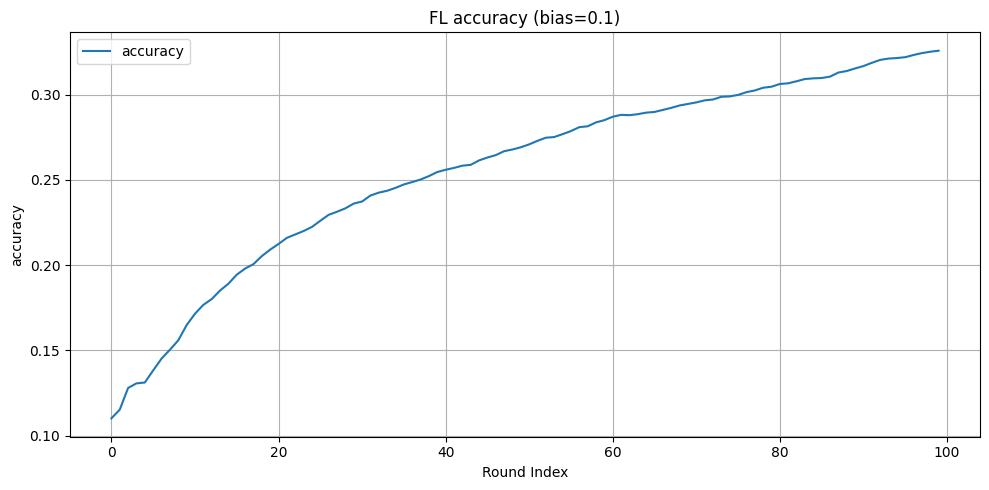

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_1, label='accuracy')
plt.title('FL accuracy (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.1

In [16]:
def lie_attack(all_updates, z):

    avg = torch.mean(all_updates, dim=0)

    std = torch.std(all_updates, dim=0)

    attacked_update = avg + z * std

    return attacked_update

In [17]:
accuracies_atk1 = []
accuracies_atk2 = []
accuracies_atk3 = []
accuracies_atk4 = []
accuracies_atk5 = []
accuracies_atk6 = []

In [18]:
%%time

import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01

# LIE attack parameter
z = 1.5  # Adjust attack strength as needed

for e in range(100):  # Training for 100 rounds
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):  # Assuming 15 clients
        net_ = copy.deepcopy(net)  # Create a local model copy
        net_.zero_grad()
        output = net_(each_worker_data[i][:])  # Forward pass with client's data
        loss = criterion(output, each_worker_label[i][:])  # Compute loss

        # Backward pass to compute gradients
        #loss.backward(retain_graph=True)
        loss.backward()

        param_grad = None
        for param in net_.parameters():
            if param_grad is None:
                param_grad = param.grad.data.view(-1)
            else:
                param_grad = torch.cat((param_grad, param.grad.data.view(-1)))
        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    agg_grads_atk = lie_attack(user_grads, z)
    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    for param in net.parameters():
        param_update = agg_grads_atk[start_idx:start_idx + param.data.numel()].reshape(param.data.shape)
        start_idx += param.data.numel()
        param.data -= lr * param_update  # Apply the update

    # Evaluate the global model
    total, correct = 0, 0
    with torch.no_grad():
        for data in test_data:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracies_atk1.append(correct/total)

Round 0, Accuracy: 0.1053
Round 1, Accuracy: 0.1126
Round 2, Accuracy: 0.1193
Round 3, Accuracy: 0.1273
Round 4, Accuracy: 0.1343
Round 5, Accuracy: 0.1400
Round 6, Accuracy: 0.1487
Round 7, Accuracy: 0.1546
Round 8, Accuracy: 0.1592
Round 9, Accuracy: 0.1619
Round 10, Accuracy: 0.1661
Round 11, Accuracy: 0.1702
Round 12, Accuracy: 0.1736
Round 13, Accuracy: 0.1759
Round 14, Accuracy: 0.1779
Round 15, Accuracy: 0.1812
Round 16, Accuracy: 0.1836
Round 17, Accuracy: 0.1867
Round 18, Accuracy: 0.1883
Round 19, Accuracy: 0.1896
Round 20, Accuracy: 0.1917
Round 21, Accuracy: 0.1940
Round 22, Accuracy: 0.1962
Round 23, Accuracy: 0.1984
Round 24, Accuracy: 0.2018
Round 25, Accuracy: 0.2035
Round 26, Accuracy: 0.2046
Round 27, Accuracy: 0.2085
Round 28, Accuracy: 0.2096
Round 29, Accuracy: 0.2111
Round 30, Accuracy: 0.2130
Round 31, Accuracy: 0.2143
Round 32, Accuracy: 0.2156
Round 33, Accuracy: 0.2162
Round 34, Accuracy: 0.2184
Round 35, Accuracy: 0.2184
Round 36, Accuracy: 0.2197
Round 37, A

### LIE Attack, bias = 0.1. # of clients = 15

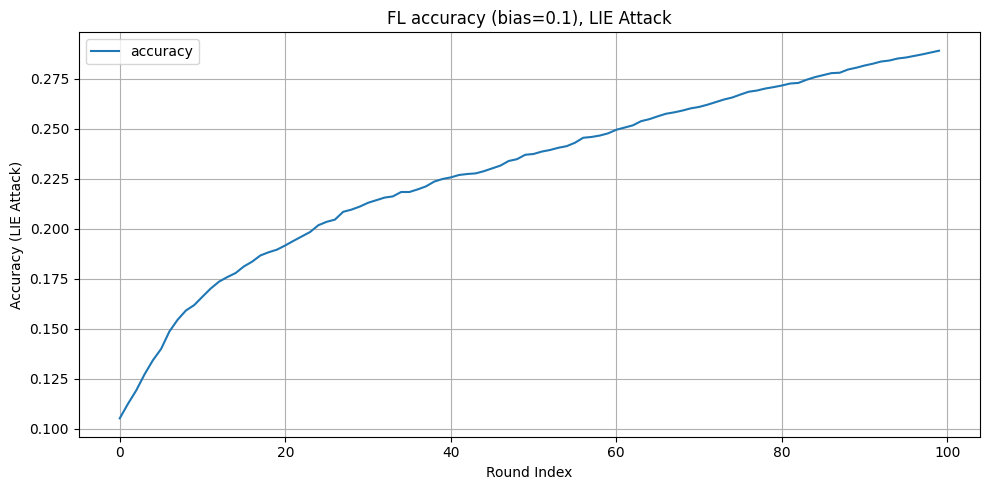

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_atk1, label='accuracy')
plt.title('FL accuracy (bias=0.1), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

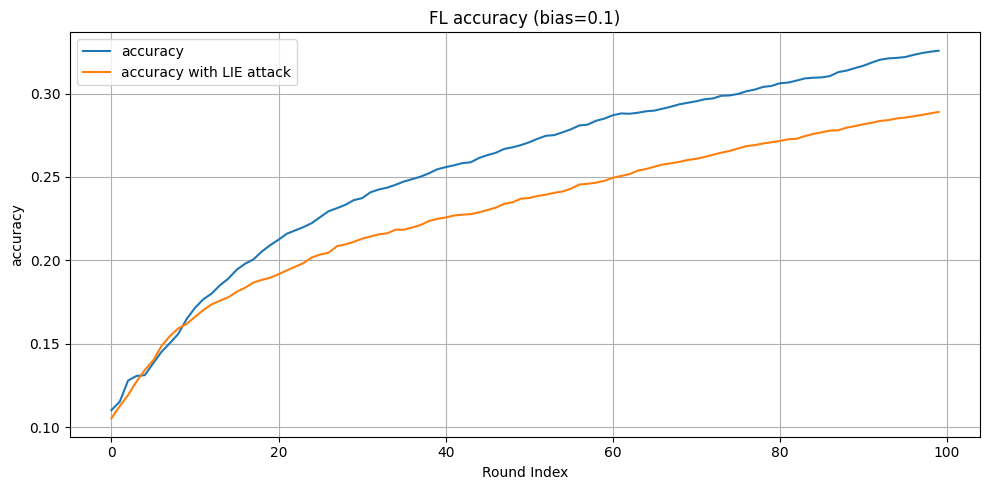

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_1, label='accuracy')
plt.plot(accuracies_atk1, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.1

In [39]:
accuracies_trim_atk1 = []
accuracies_trim_atk2 = []
accuracies_trim_atk3 = []
accuracies_trim_atk4 = []
accuracies_trim_atk5 = []
accuracies_trim_atk6 = []
accuracies_trim_atk7 = []
accuracies_trim_atk8 = []
accuracies_trim_atk9 = []
accuracies_trim_atk10 = []
accuracies_trim_atk11 = []
accuracies_trim_atk12 = []

In [40]:
#Static 
#This is the attack.
def full_trim(v, f):
    '''
    Full-knowledge Trim attack. w.l.o.g., we assume the first f worker devices are compromised.
    v: the list of squeezed gradients
    f: the number of compromised worker devices
    '''
    # first compute the statistics
    vi_shape = v[0].unsqueeze(0).T.shape
    v_tran = v.T
#     v_tran = nd.concat(*v, dim=1)
    
    maximum_dim = torch.max(v_tran, dim=1)
    maximum_dim = maximum_dim[0].reshape(vi_shape)
    minimum_dim = torch.min(v_tran, dim=1)
    minimum_dim = minimum_dim[0].reshape(vi_shape)
    direction = torch.sign(torch.sum(v_tran, dim=-1, keepdims=True))
    directed_dim = (direction > 0) * minimum_dim + (direction < 0) * maximum_dim

    for i in range(f):
        # apply attack to compromised worker devices with randomness
        random_12 = 2
        tmp = directed_dim * ((direction * directed_dim > 0) / random_12 + (direction * directed_dim < 0) * random_12)
        tmp = tmp.squeeze()
        v[i] = tmp
    return v

In [41]:
%%time

import torch
import copy
import pickle

# Now, let's integrate this into your FL training loop
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        loss.backward() 

        # Flatten and store gradients
        param_grad = []
        for param in net_.parameters():
            param_grad = param.grad.data.view(-1) if len(param_grad) == 0 else torch.cat((param_grad, param.grad.data.view(-1)))

        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    user_grads = full_trim(user_grads, compromised_workers)

    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    # Update the model with aggregated gradients
    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []

    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracies_trim_atk1.append(correct/total)

Round 0, Accuracy: 0.0961
Round 1, Accuracy: 0.0792
Round 2, Accuracy: 0.1018
Round 3, Accuracy: 0.1165
Round 4, Accuracy: 0.1212
Round 5, Accuracy: 0.1269
Round 6, Accuracy: 0.1322
Round 7, Accuracy: 0.1390
Round 8, Accuracy: 0.1443
Round 9, Accuracy: 0.1480
Round 10, Accuracy: 0.1544
Round 11, Accuracy: 0.1583
Round 12, Accuracy: 0.1630
Round 13, Accuracy: 0.1691
Round 14, Accuracy: 0.1758
Round 15, Accuracy: 0.1801
Round 16, Accuracy: 0.1839
Round 17, Accuracy: 0.1901
Round 18, Accuracy: 0.1967
Round 19, Accuracy: 0.2013
Round 20, Accuracy: 0.2062
Round 21, Accuracy: 0.2095
Round 22, Accuracy: 0.2122
Round 23, Accuracy: 0.2146
Round 24, Accuracy: 0.2170
Round 25, Accuracy: 0.2191
Round 26, Accuracy: 0.2215
Round 27, Accuracy: 0.2253
Round 28, Accuracy: 0.2266
Round 29, Accuracy: 0.2296
Round 30, Accuracy: 0.2334
Round 31, Accuracy: 0.2380
Round 32, Accuracy: 0.2408
Round 33, Accuracy: 0.2422
Round 34, Accuracy: 0.2453
Round 35, Accuracy: 0.2483
Round 36, Accuracy: 0.2496
Round 37, A

### full_trim attack, bias = 0.1, 15 clients

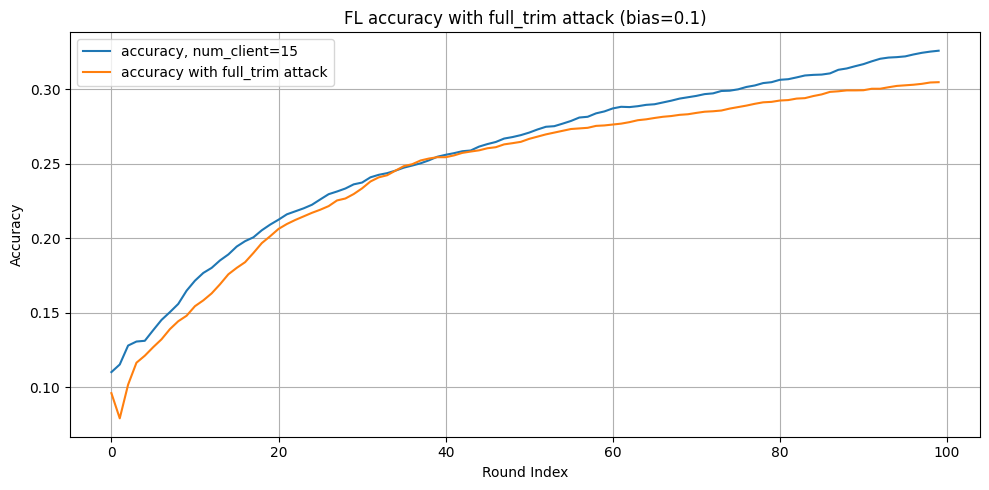

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_1, label='accuracy, num_client=15')
plt.plot(accuracies_trim_atk1, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracies_2

In [42]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        #loss.backward(retain_graph = True)
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates
    print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
#         param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracies_2.append(correct/total)

15
0 0.0971
15
1 0.0995
15
2 0.1087
15
3 0.1181
15
4 0.1261
15
5 0.1331
15
6 0.1411
15
7 0.1475
15
8 0.1554
15
9 0.1603
15
10 0.1641
15
11 0.1701
15
12 0.1754
15
13 0.1794
15
14 0.1837
15
15 0.1883
15
16 0.193
15
17 0.1971
15
18 0.2018
15
19 0.2066
15
20 0.2107
15
21 0.2137
15
22 0.2165
15
23 0.2181
15
24 0.2217
15
25 0.2252
15
26 0.2289
15
27 0.2318
15
28 0.2338
15
29 0.2362
15
30 0.2378
15
31 0.2415
15
32 0.2441
15
33 0.2474
15
34 0.2499
15
35 0.2521
15
36 0.2531
15
37 0.2545
15
38 0.2563
15
39 0.2589
15
40 0.2599
15
41 0.2603
15
42 0.2618
15
43 0.2636
15
44 0.2656
15
45 0.2675
15
46 0.2678
15
47 0.2686
15
48 0.2698
15
49 0.2711
15
50 0.273
15
51 0.2742
15
52 0.2751
15
53 0.2765
15
54 0.2779
15
55 0.2788
15
56 0.2798
15
57 0.2811
15
58 0.2818
15
59 0.282
15
60 0.2834
15
61 0.2858
15
62 0.2865
15
63 0.2884
15
64 0.2902
15
65 0.2915
15
66 0.2921
15
67 0.2937
15
68 0.2949
15
69 0.2965
15
70 0.2968
15
71 0.2982
15
72 0.2995
15
73 0.3001
15
74 0.3011
15
75 0.3017
15
76 0.3031
15
77 0.3044

### 3 graphs for full_trim, bias = 0.1

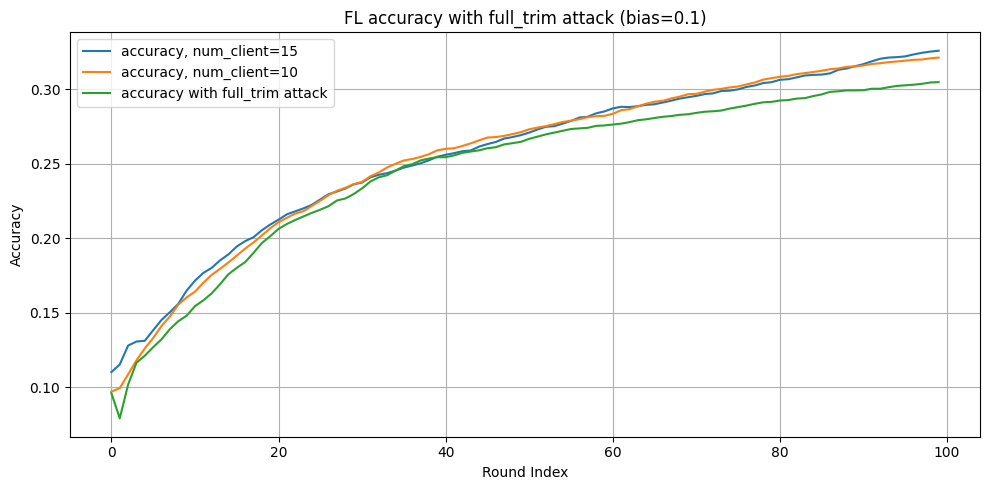

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_1, label='accuracy, num_client=15')
plt.plot(accuracies_2, label='accuracy, num_client=10')
plt.plot(accuracies_trim_atk1, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [131]:
#This is the defense. It performs dimension-wise filtering of the model updates i.e., it chops off the outliers.
def tr_mean(all_updates, n_attackers):
    sorted_updates = torch.sort(all_updates, 0)[0]
    out = torch.mean(sorted_updates[n_attackers:-n_attackers], 0) if n_attackers else torch.mean(sorted_updates,0)
    return out

In [47]:
%%time

import torch
import copy
import pickle

# Now, let's integrate this into your FL training loop
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        #loss.backward(retain_graph=True)
        loss.backward() 

        # Flatten and store gradients
        param_grad = []
        for param in net_.parameters():
            param_grad = param.grad.data.view(-1) if len(param_grad) == 0 else torch.cat((param_grad, param.grad.data.view(-1)))

        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    user_grads = full_trim(user_grads, compromised_workers)

    # Aggregate gradients by averaging
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    # Update the model with aggregated gradients
    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []

    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracies_trim_atk3.append(correct/total)

Round 0, Accuracy: 0.0996
Round 1, Accuracy: 0.0768
Round 2, Accuracy: 0.0891
Round 3, Accuracy: 0.0981
Round 4, Accuracy: 0.1055
Round 5, Accuracy: 0.1109
Round 6, Accuracy: 0.1160
Round 7, Accuracy: 0.1196
Round 8, Accuracy: 0.1235
Round 9, Accuracy: 0.1301
Round 10, Accuracy: 0.1358
Round 11, Accuracy: 0.1389
Round 12, Accuracy: 0.1433
Round 13, Accuracy: 0.1481
Round 14, Accuracy: 0.1519
Round 15, Accuracy: 0.1561
Round 16, Accuracy: 0.1611
Round 17, Accuracy: 0.1646
Round 18, Accuracy: 0.1678
Round 19, Accuracy: 0.1703
Round 20, Accuracy: 0.1744
Round 21, Accuracy: 0.1785
Round 22, Accuracy: 0.1814
Round 23, Accuracy: 0.1844
Round 24, Accuracy: 0.1873
Round 25, Accuracy: 0.1882
Round 26, Accuracy: 0.1928
Round 27, Accuracy: 0.1957
Round 28, Accuracy: 0.1978
Round 29, Accuracy: 0.2007
Round 30, Accuracy: 0.2027
Round 31, Accuracy: 0.2048
Round 32, Accuracy: 0.2069
Round 33, Accuracy: 0.2095
Round 34, Accuracy: 0.2108
Round 35, Accuracy: 0.2135
Round 36, Accuracy: 0.2154
Round 37, A

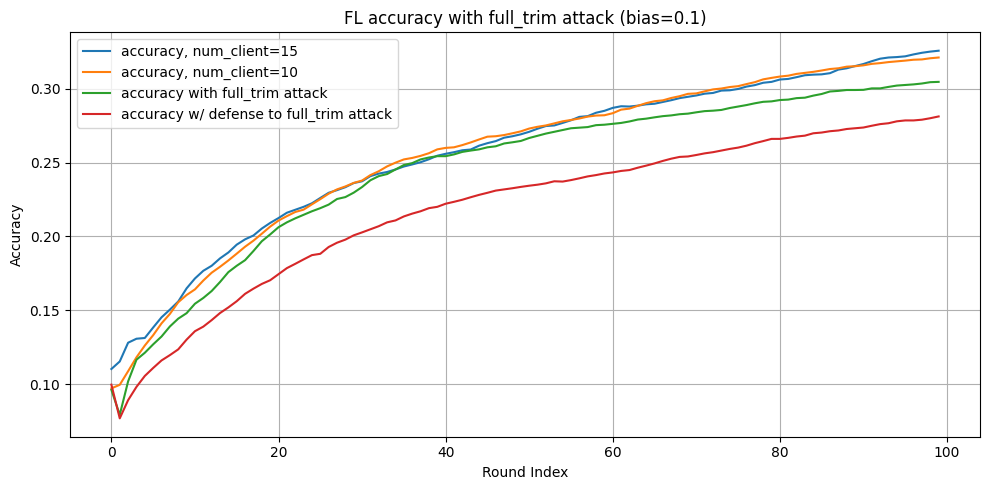

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_1, label='accuracy, num_client=15')
plt.plot(accuracies_2, label='accuracy, num_client=10')
plt.plot(accuracies_trim_atk1, label='accuracy with full_trim attack')
plt.plot(accuracies_trim_atk3, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# bias = 0.5, # of clients = 15
# ===============================

In [64]:
bias = 0.5
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [65]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_105230/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [66]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [67]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [68]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_5

In [69]:
accuracy_bias_0_5 = []

In [70]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates
    print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5.append(correct/total)

15
0 0.108
15
1 0.1133
15
2 0.1106
15
3 0.1125
15
4 0.1166
15
5 0.1215
15
6 0.1262
15
7 0.1313
15
8 0.1361
15
9 0.1418
15
10 0.1486
15
11 0.1555
15
12 0.1604
15
13 0.1683
15
14 0.1746
15
15 0.1805
15
16 0.1849
15
17 0.1889
15
18 0.1947
15
19 0.2001
15
20 0.2026
15
21 0.2069
15
22 0.2117
15
23 0.2163
15
24 0.2194
15
25 0.2243
15
26 0.2279
15
27 0.2297
15
28 0.2317
15
29 0.2356
15
30 0.2377
15
31 0.2397
15
32 0.2419
15
33 0.2429
15
34 0.2449
15
35 0.2474
15
36 0.25
15
37 0.2526
15
38 0.2551
15
39 0.2571
15
40 0.2603
15
41 0.2632
15
42 0.2657
15
43 0.2675
15
44 0.2697
15
45 0.2719
15
46 0.2728
15
47 0.2748
15
48 0.2763
15
49 0.2778
15
50 0.2793
15
51 0.2799
15
52 0.2816
15
53 0.2826
15
54 0.2843
15
55 0.2842
15
56 0.2843
15
57 0.2855
15
58 0.2868
15
59 0.2875
15
60 0.2878
15
61 0.289
15
62 0.2899
15
63 0.2911
15
64 0.2919
15
65 0.2931
15
66 0.2942
15
67 0.2961
15
68 0.2965
15
69 0.2973
15
70 0.2973
15
71 0.2983
15
72 0.2994
15
73 0.3003
15
74 0.301
15
75 0.3012
15
76 0.3029
15
77 0.304
15

### Displaying results, bias = 0.5. # of clients = 15

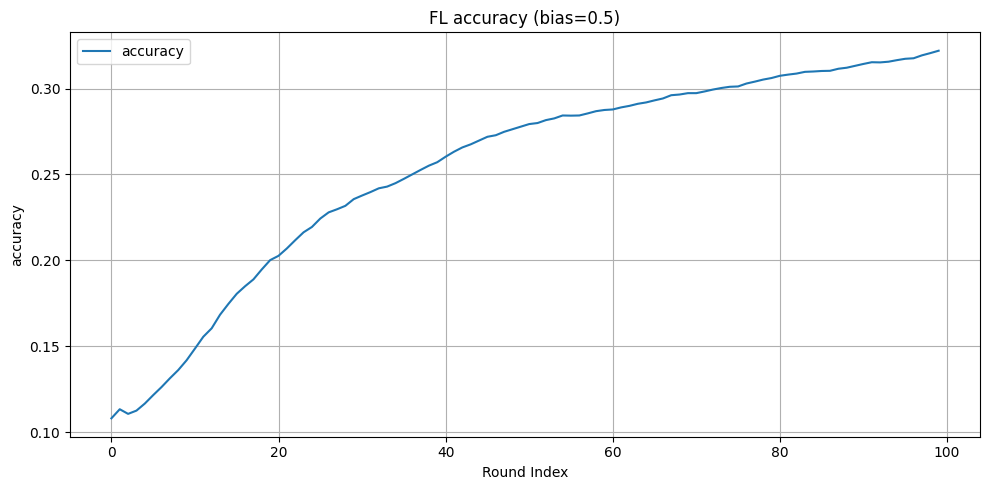

In [71]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy')
plt.title('FL accuracy (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.5

In [72]:
accuracy_bias_0_5_lie_attack = []

### saving to accuracy_bias_0_5_lie_attack

In [73]:
%%time

import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01

# LIE attack parameter
z = 1.5  # Adjust attack strength as needed

for e in range(100):  # Training for 100 rounds
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):  # Assuming 15 clients
        net_ = copy.deepcopy(net)  # Create a local model copy
        net_.zero_grad()
        output = net_(each_worker_data[i][:])  # Forward pass with client's data
        loss = criterion(output, each_worker_label[i][:])  # Compute loss

        # Backward pass to compute gradients
        loss.backward()

        param_grad = None
        for param in net_.parameters():
            if param_grad is None:  # Initialize the first gradient
                param_grad = param.grad.data.view(-1)
            else:
                param_grad = torch.cat((param_grad, param.grad.data.view(-1)))
        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    agg_grads_atk = lie_attack(user_grads, z)
    del user_grads

    # Update the global model using attacked gradients
    start_idx = 0
    cnn_optimizer.zero_grad()
    for param in net.parameters():
        param_update = agg_grads_atk[start_idx:start_idx + param.data.numel()].reshape(param.data.shape)
        start_idx += param.data.numel()
        param.data -= lr * param_update  # Apply the update

    # Evaluate the global model
    total, correct = 0, 0
    with torch.no_grad():
        for data in test_data:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracy_bias_0_5_lie_attack.append(correct/total)

Round 0, Accuracy: 0.0945
Round 1, Accuracy: 0.1060
Round 2, Accuracy: 0.1131
Round 3, Accuracy: 0.1179
Round 4, Accuracy: 0.1190
Round 5, Accuracy: 0.1193
Round 6, Accuracy: 0.1223
Round 7, Accuracy: 0.1231
Round 8, Accuracy: 0.1232
Round 9, Accuracy: 0.1252
Round 10, Accuracy: 0.1265
Round 11, Accuracy: 0.1293
Round 12, Accuracy: 0.1291
Round 13, Accuracy: 0.1286
Round 14, Accuracy: 0.1306
Round 15, Accuracy: 0.1337
Round 16, Accuracy: 0.1363
Round 17, Accuracy: 0.1362
Round 18, Accuracy: 0.1375
Round 19, Accuracy: 0.1383
Round 20, Accuracy: 0.1393
Round 21, Accuracy: 0.1396
Round 22, Accuracy: 0.1406
Round 23, Accuracy: 0.1419
Round 24, Accuracy: 0.1427
Round 25, Accuracy: 0.1432
Round 26, Accuracy: 0.1427
Round 27, Accuracy: 0.1419
Round 28, Accuracy: 0.1417
Round 29, Accuracy: 0.1413
Round 30, Accuracy: 0.1411
Round 31, Accuracy: 0.1427
Round 32, Accuracy: 0.1419
Round 33, Accuracy: 0.1414
Round 34, Accuracy: 0.1404
Round 35, Accuracy: 0.1399
Round 36, Accuracy: 0.1405
Round 37, A

### LIE Attack, bias = 0.5. # of clients = 15

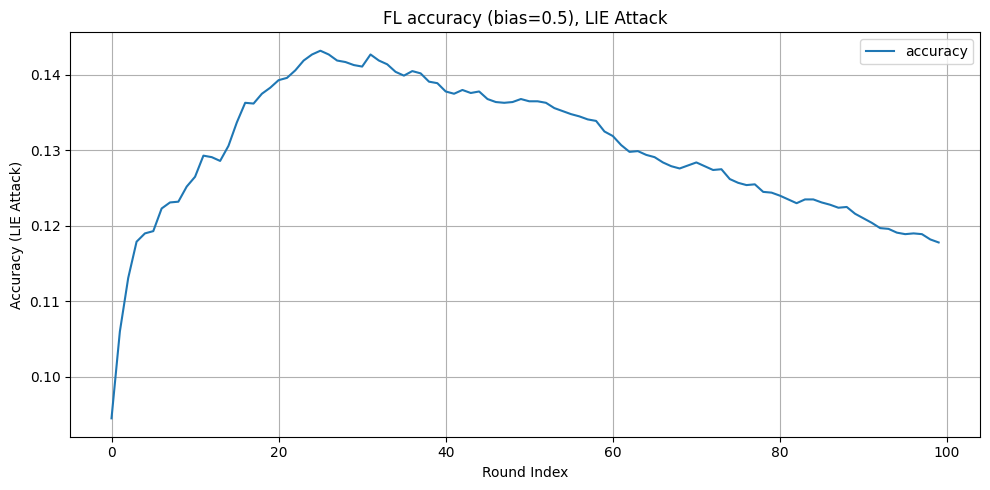

In [74]:
plt.figure(figsize=(10, 5))
plt.plot( accuracy_bias_0_5_lie_attack, label='accuracy')
plt.title('FL accuracy (bias=0.5), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

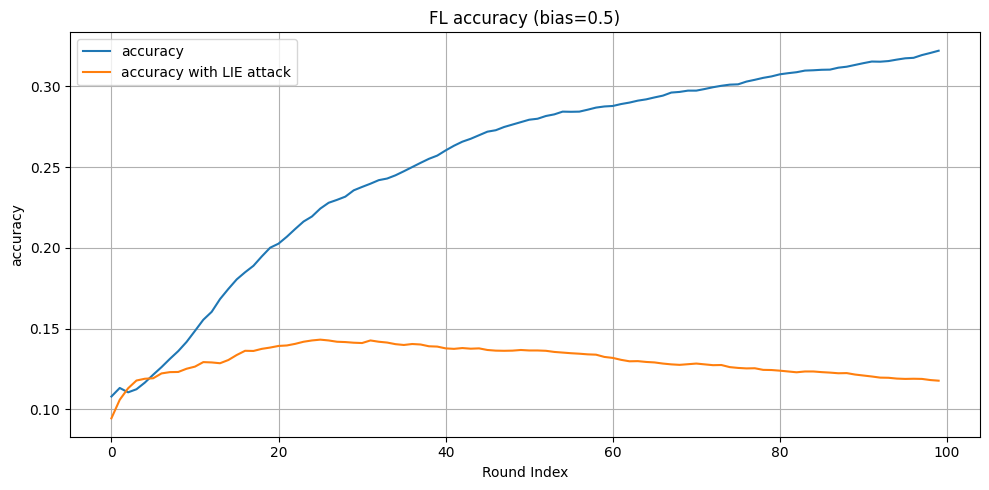

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy')
plt.plot( accuracy_bias_0_5_lie_attack, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.5

In [76]:
accuracy_bias_0_5_full_trim_attack = []

In [77]:
%%time

import torch
import copy
import pickle

# Now, let's integrate this into your FL training loop
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        #loss.backward(retain_graph=True)
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad = param.grad.data.view(-1) if len(param_grad) == 0 else torch.cat((param_grad, param.grad.data.view(-1)))

        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    user_grads = full_trim(user_grads, compromised_workers)

    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracy_bias_0_5_full_trim_attack.append(correct/total)

Round 0, Accuracy: 0.1110
Round 1, Accuracy: 0.0980
Round 2, Accuracy: 0.1045
Round 3, Accuracy: 0.1026
Round 4, Accuracy: 0.1047
Round 5, Accuracy: 0.1057
Round 6, Accuracy: 0.1068
Round 7, Accuracy: 0.1090
Round 8, Accuracy: 0.1101
Round 9, Accuracy: 0.1114
Round 10, Accuracy: 0.1142
Round 11, Accuracy: 0.1163
Round 12, Accuracy: 0.1183
Round 13, Accuracy: 0.1202
Round 14, Accuracy: 0.1209
Round 15, Accuracy: 0.1214
Round 16, Accuracy: 0.1228
Round 17, Accuracy: 0.1250
Round 18, Accuracy: 0.1263
Round 19, Accuracy: 0.1272
Round 20, Accuracy: 0.1278
Round 21, Accuracy: 0.1292
Round 22, Accuracy: 0.1308
Round 23, Accuracy: 0.1323
Round 24, Accuracy: 0.1332
Round 25, Accuracy: 0.1338
Round 26, Accuracy: 0.1350
Round 27, Accuracy: 0.1366
Round 28, Accuracy: 0.1367
Round 29, Accuracy: 0.1373
Round 30, Accuracy: 0.1392
Round 31, Accuracy: 0.1396
Round 32, Accuracy: 0.1416
Round 33, Accuracy: 0.1423
Round 34, Accuracy: 0.1423
Round 35, Accuracy: 0.1434
Round 36, Accuracy: 0.1445
Round 37, A

### full_trim attack, bias = 0.5, 15 clients

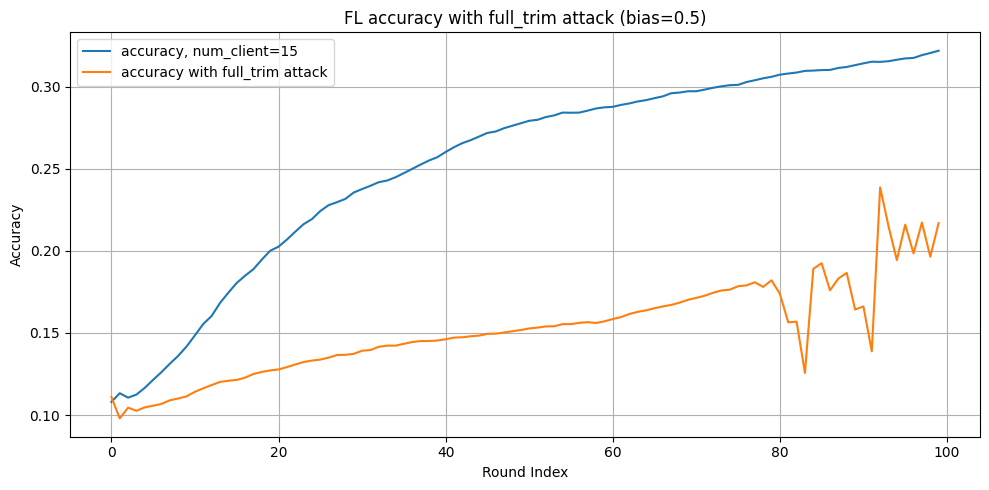

In [83]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracy_bias_0_5_clients_10

In [84]:
accuracy_bias_0_5_clients_10 = []

In [85]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates
    #print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_clients_10.append(correct/total)

15
0 0.1012
15
1 0.1007
15
2 0.1039
15
3 0.1113
15
4 0.1142
15
5 0.1172
15
6 0.1215
15
7 0.1246
15
8 0.1314
15
9 0.1344
15
10 0.1382
15
11 0.1423
15
12 0.1466
15
13 0.1508
15
14 0.1558
15
15 0.1601
15
16 0.1638
15
17 0.1674
15
18 0.1697
15
19 0.1738
15
20 0.1771
15
21 0.1803
15
22 0.1852
15
23 0.1883
15
24 0.1912
15
25 0.195
15
26 0.1976
15
27 0.1999
15
28 0.2017
15
29 0.2047
15
30 0.2076
15
31 0.2112
15
32 0.214
15
33 0.2159
15
34 0.2181
15
35 0.2205
15
36 0.2214
15
37 0.2229
15
38 0.2246
15
39 0.2264
15
40 0.2294
15
41 0.2298
15
42 0.2315
15
43 0.2334
15
44 0.2339
15
45 0.2366
15
46 0.2379
15
47 0.2405
15
48 0.2414
15
49 0.2431
15
50 0.2447
15
51 0.2456
15
52 0.2466
15
53 0.2473
15
54 0.2482
15
55 0.2492
15
56 0.251
15
57 0.2514
15
58 0.252
15
59 0.253
15
60 0.2533
15
61 0.2546
15
62 0.2553
15
63 0.2562
15
64 0.2576
15
65 0.2596
15
66 0.2615
15
67 0.263
15
68 0.2642
15
69 0.2657
15
70 0.2667
15
71 0.2678
15
72 0.27
15
73 0.2711
15
74 0.272
15
75 0.2738
15
76 0.2743
15
77 0.275
15
78 

### 3 graphs for full_trim, bias = 0.5

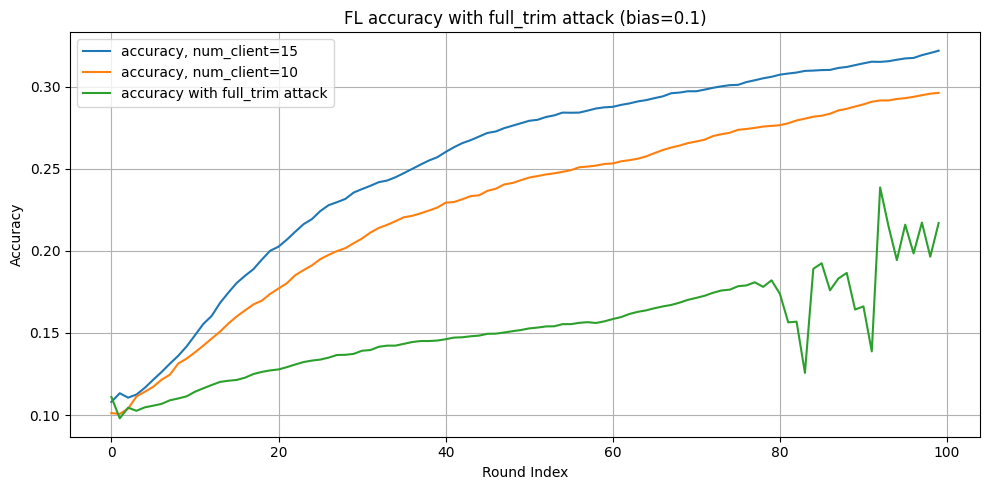

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [88]:
accuracy_bias_0_5_full_trim_defense = []

In [89]:
%%time

import pickle

net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad = param.grad.data.view(-1) if len(param_grad) == 0 else torch.cat((param_grad, param.grad.data.view(-1)))

        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    user_grads = full_trim(user_grads, compromised_workers)

    # Aggregate gradients by averaging
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []

    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracy_bias_0_5_full_trim_defense.append(correct/total)

Round 0, Accuracy: 0.1020
Round 1, Accuracy: 0.1043
Round 2, Accuracy: 0.1071
Round 3, Accuracy: 0.1083
Round 4, Accuracy: 0.1081
Round 5, Accuracy: 0.1081
Round 6, Accuracy: 0.1088
Round 7, Accuracy: 0.1106
Round 8, Accuracy: 0.1113
Round 9, Accuracy: 0.1123
Round 10, Accuracy: 0.1129
Round 11, Accuracy: 0.1135
Round 12, Accuracy: 0.1159
Round 13, Accuracy: 0.1165
Round 14, Accuracy: 0.1177
Round 15, Accuracy: 0.1182
Round 16, Accuracy: 0.1200
Round 17, Accuracy: 0.1212
Round 18, Accuracy: 0.1226
Round 19, Accuracy: 0.1236
Round 20, Accuracy: 0.1240
Round 21, Accuracy: 0.1256
Round 22, Accuracy: 0.1258
Round 23, Accuracy: 0.1276
Round 24, Accuracy: 0.1292
Round 25, Accuracy: 0.1309
Round 26, Accuracy: 0.1317
Round 27, Accuracy: 0.1320
Round 28, Accuracy: 0.1325
Round 29, Accuracy: 0.1342
Round 30, Accuracy: 0.1348
Round 31, Accuracy: 0.1365
Round 32, Accuracy: 0.1363
Round 33, Accuracy: 0.1366
Round 34, Accuracy: 0.1369
Round 35, Accuracy: 0.1378
Round 36, Accuracy: 0.1388
Round 37, A

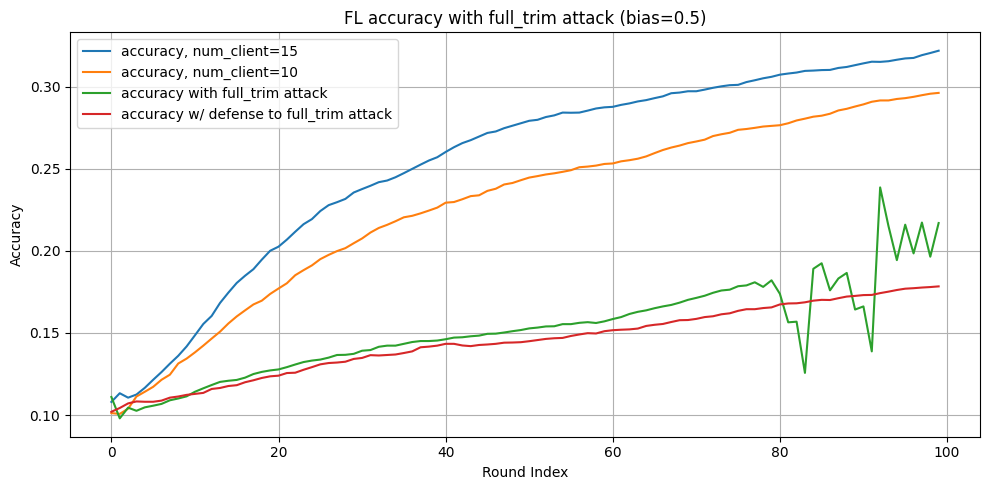

In [90]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_5_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =======================
# CHANGING TO BIAS = 0.9
# =======================

# bias = 0.9, # of clients = 15





In [100]:
bias = 0.9
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [101]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_105230/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [102]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [103]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [104]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_9

In [105]:
accuracy_bias_0_9 = []

In [106]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates
    #print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9.append(correct/total)

0 0.1083
1 0.1183
2 0.1146
3 0.1281
4 0.138
5 0.1402
6 0.1451
7 0.1489
8 0.1536
9 0.1576
10 0.163
11 0.1684
12 0.1726
13 0.1759
14 0.1798
15 0.1829
16 0.188
17 0.1938
18 0.1996
19 0.2037
20 0.2079
21 0.2123
22 0.2156
23 0.2178
24 0.2217
25 0.2263
26 0.2301
27 0.2328
28 0.2375
29 0.2426
30 0.2456
31 0.2475
32 0.2502
33 0.252
34 0.2528
35 0.2547
36 0.2582
37 0.2606
38 0.2605
39 0.2629
40 0.2658
41 0.2691
42 0.2707
43 0.2725
44 0.2738
45 0.2758
46 0.2766
47 0.2776
48 0.2794
49 0.2803
50 0.2819
51 0.2826
52 0.2831
53 0.2856
54 0.2853
55 0.2857
56 0.2884
57 0.29
58 0.2906
59 0.292
60 0.2932
61 0.2943
62 0.2949
63 0.2961
64 0.2977
65 0.2985
66 0.2985
67 0.2998
68 0.3004
69 0.3017
70 0.3019
71 0.3028
72 0.3029
73 0.3023
74 0.3034
75 0.3039
76 0.3052
77 0.3056
78 0.3066
79 0.3071
80 0.308
81 0.3087
82 0.3096
83 0.31
84 0.3115
85 0.3122
86 0.3124
87 0.3128
88 0.3131
89 0.313
90 0.3137
91 0.3143
92 0.3158
93 0.3168
94 0.3174
95 0.3179
96 0.3185
97 0.3191
98 0.3199
99 0.3206
CPU times: user 2min 

### Displaying results, bias = 0.9. # of clients = 15

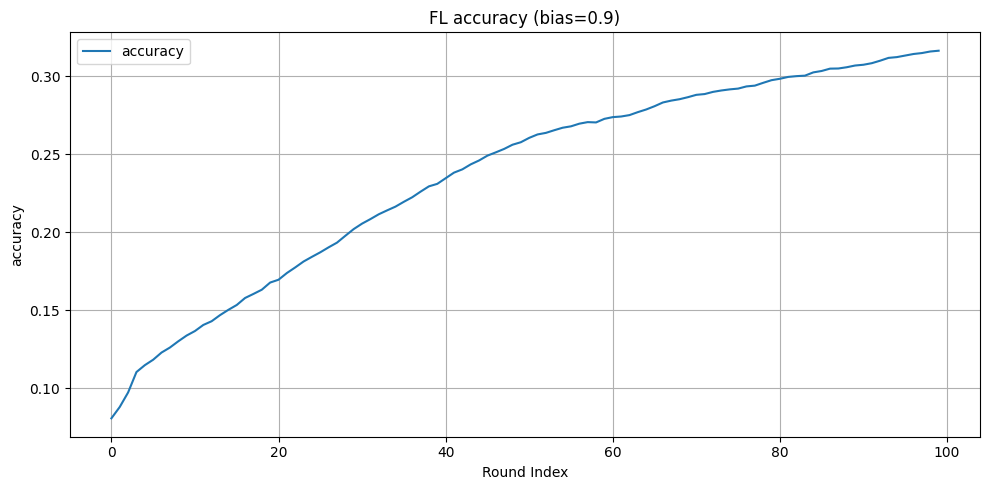

In [161]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9_redo, label='accuracy')
plt.title('FL accuracy (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.9

In [108]:
accuracy_bias_0_9_lie_attack = []

### saving to accuracy_bias_0_9_lie_attack

In [109]:
%%time

import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01

# LIE attack parameter
z = 1.5  # Adjust attack strength as needed

for e in range(100):  # Training for 100 rounds
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):  # Assuming 15 clients
        net_ = copy.deepcopy(net)  # Create a local model copy
        net_.zero_grad()
        output = net_(each_worker_data[i][:])  # Forward pass with client's data
        loss = criterion(output, each_worker_label[i][:])  # Compute loss

        # Backward pass to compute gradients
        loss.backward()

        param_grad = None
        for param in net_.parameters():
            if param_grad is None:
                param_grad = param.grad.data.view(-1)
            else:
                param_grad = torch.cat((param_grad, param.grad.data.view(-1)))
        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    agg_grads_atk = lie_attack(user_grads, z)
    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    for param in net.parameters():
        param_update = agg_grads_atk[start_idx:start_idx + param.data.numel()].reshape(param.data.shape)
        start_idx += param.data.numel()
        param.data -= lr * param_update  # Apply the update

    # Evaluate the global model
    total, correct = 0, 0
    with torch.no_grad():
        for data in test_data:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracy_bias_0_9_lie_attack.append(correct/total)

Round 0, Accuracy: 0.1008
Round 1, Accuracy: 0.0974
Round 2, Accuracy: 0.0899
Round 3, Accuracy: 0.0881
Round 4, Accuracy: 0.0869
Round 5, Accuracy: 0.0884
Round 6, Accuracy: 0.0904
Round 7, Accuracy: 0.0947
Round 8, Accuracy: 0.0984
Round 9, Accuracy: 0.1015
Round 10, Accuracy: 0.1049
Round 11, Accuracy: 0.1073
Round 12, Accuracy: 0.1098
Round 13, Accuracy: 0.1129
Round 14, Accuracy: 0.1170
Round 15, Accuracy: 0.1165
Round 16, Accuracy: 0.1173
Round 17, Accuracy: 0.1190
Round 18, Accuracy: 0.1184
Round 19, Accuracy: 0.1187
Round 20, Accuracy: 0.1185
Round 21, Accuracy: 0.1195
Round 22, Accuracy: 0.1197
Round 23, Accuracy: 0.1194
Round 24, Accuracy: 0.1200
Round 25, Accuracy: 0.1212
Round 26, Accuracy: 0.1207
Round 27, Accuracy: 0.1213
Round 28, Accuracy: 0.1209
Round 29, Accuracy: 0.1206
Round 30, Accuracy: 0.1210
Round 31, Accuracy: 0.1211
Round 32, Accuracy: 0.1208
Round 33, Accuracy: 0.1210
Round 34, Accuracy: 0.1209
Round 35, Accuracy: 0.1210
Round 36, Accuracy: 0.1203
Round 37, A

### LIE Attack, bias = 0.9. # of clients = 15

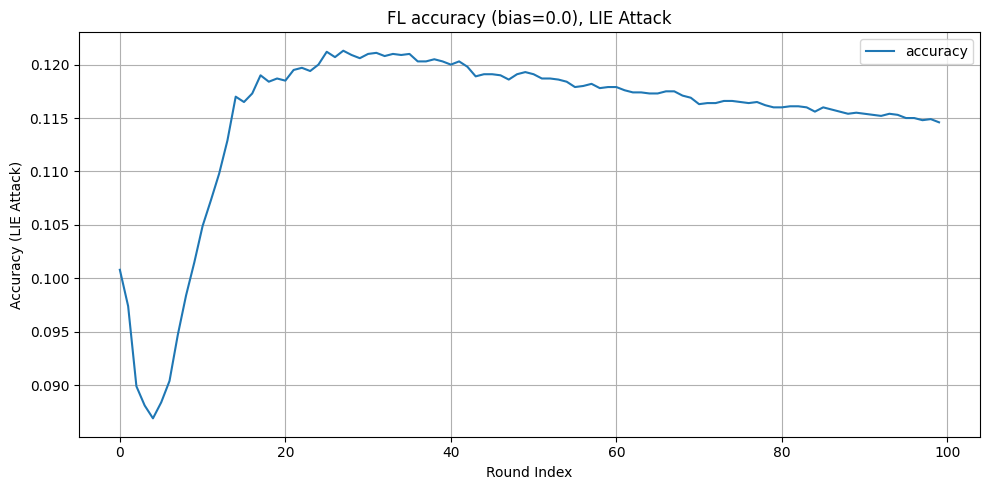

In [110]:
plt.figure(figsize=(10, 5))
plt.plot( accuracy_bias_0_9_lie_attack, label='accuracy')
plt.title('FL accuracy (bias=0.0), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

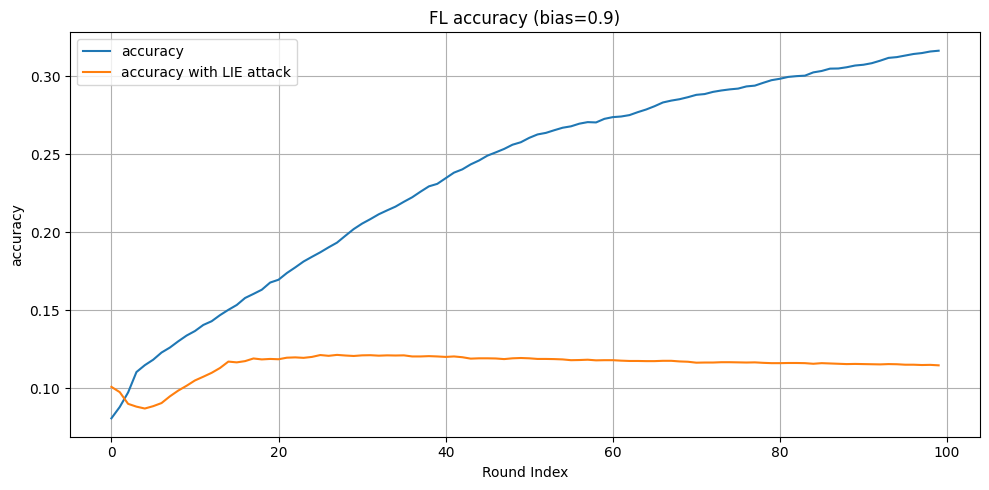

In [162]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9_redo, label='accuracy')
plt.plot( accuracy_bias_0_9_lie_attack, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.9

In [120]:
accuracy_bias_0_9_full_trim_attack = []

In [121]:
%%time

import pickle

net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        #loss.backward(retain_graph=True)
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad = param.grad.data.view(-1) if len(param_grad) == 0 else torch.cat((param_grad, param.grad.data.view(-1)))

        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    user_grads = full_trim(user_grads, compromised_workers)

    # Aggregate gradients by averaging
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []

    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracy_bias_0_9_full_trim_attack.append(correct/total)

Round 0, Accuracy: 0.1000
Round 1, Accuracy: 0.1000
Round 2, Accuracy: 0.1000
Round 3, Accuracy: 0.1000
Round 4, Accuracy: 0.1000
Round 5, Accuracy: 0.1000
Round 6, Accuracy: 0.1000
Round 7, Accuracy: 0.0997
Round 8, Accuracy: 0.1002
Round 9, Accuracy: 0.1003
Round 10, Accuracy: 0.1012
Round 11, Accuracy: 0.1004
Round 12, Accuracy: 0.1033
Round 13, Accuracy: 0.1014
Round 14, Accuracy: 0.1038
Round 15, Accuracy: 0.1023
Round 16, Accuracy: 0.1046
Round 17, Accuracy: 0.1026
Round 18, Accuracy: 0.1024
Round 19, Accuracy: 0.1025
Round 20, Accuracy: 0.1034
Round 21, Accuracy: 0.1033
Round 22, Accuracy: 0.1037
Round 23, Accuracy: 0.1050
Round 24, Accuracy: 0.1054
Round 25, Accuracy: 0.1085
Round 26, Accuracy: 0.1088
Round 27, Accuracy: 0.1131
Round 28, Accuracy: 0.1156
Round 29, Accuracy: 0.1192
Round 30, Accuracy: 0.1245
Round 31, Accuracy: 0.1192
Round 32, Accuracy: 0.1254
Round 33, Accuracy: 0.1111
Round 34, Accuracy: 0.1112
Round 35, Accuracy: 0.1003
Round 36, Accuracy: 0.1000
Round 37, A

### full_trim attack, bias = 0.9, 15 clients

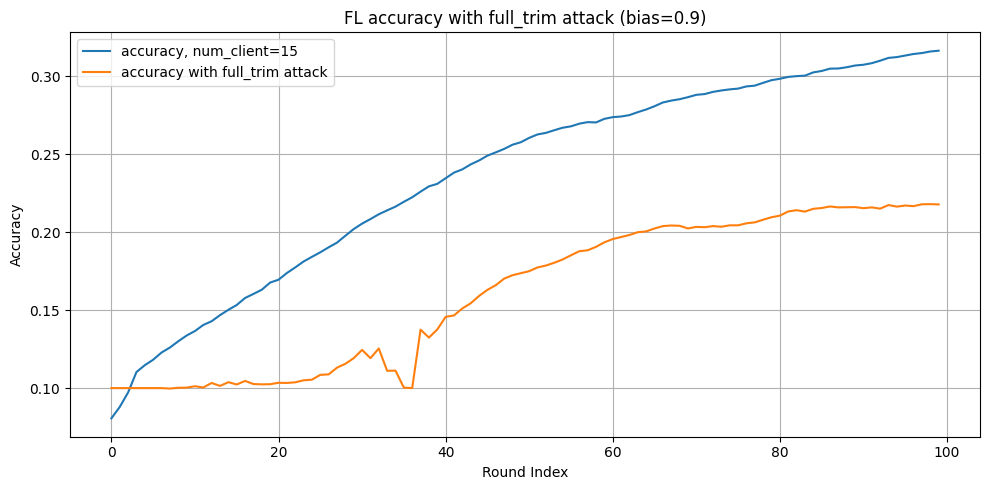

In [163]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9_redo, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracy_bias_0_9_clients_10

In [116]:
accuracy_bias_0_9_clients_10 = []

In [165]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates
    #print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_clients_10.append(correct/total)

0 0.1044
1 0.1439
2 0.1453
3 0.1655
4 0.1654
5 0.1682
6 0.1723
7 0.1755
8 0.1783
9 0.181
10 0.185
11 0.1861
12 0.1886
13 0.1904
14 0.1919
15 0.1929
16 0.1951
17 0.1956
18 0.1967
19 0.1976
20 0.199
21 0.2005
22 0.2007
23 0.2012
24 0.2024
25 0.2035
26 0.2035
27 0.2042
28 0.2051
29 0.2054
30 0.2056
31 0.206
32 0.2063
33 0.2063
34 0.2064
35 0.207
36 0.2074
37 0.2081
38 0.2087
39 0.2095
40 0.2096
41 0.2106
42 0.2112
43 0.2118
44 0.2123
45 0.2128
46 0.2139
47 0.2148
48 0.2157
49 0.2162
50 0.2175
51 0.2184
52 0.2195
53 0.2207
54 0.2215
55 0.2226
56 0.2243
57 0.2257
58 0.2267
59 0.227
60 0.2288
61 0.229
62 0.2301
63 0.2314
64 0.233
65 0.2343
66 0.236
67 0.2369
68 0.2376
69 0.2388
70 0.2396
71 0.2413
72 0.244
73 0.2455
74 0.2475
75 0.2488
76 0.2499
77 0.2505
78 0.252
79 0.253
80 0.2534
81 0.255
82 0.2555
83 0.2563
84 0.2579
85 0.2589
86 0.2592
87 0.2594
88 0.2607
89 0.2608
90 0.2621
91 0.2626
92 0.2637
93 0.2649
94 0.2655
95 0.2659
96 0.2669
97 0.2679
98 0.2686
99 0.27
CPU times: user 2min 12s,

### 3 graphs for full_trim, bias = 0.9

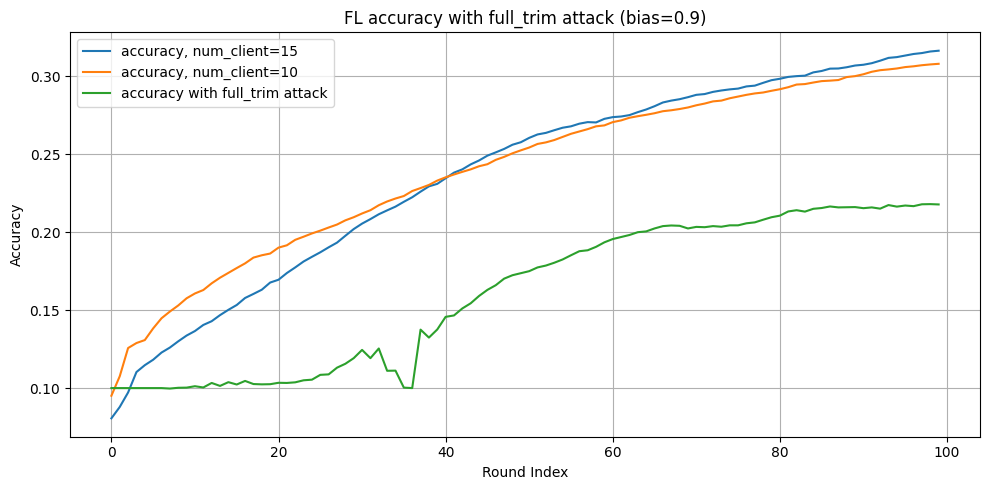

In [187]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9_redo, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [132]:
accuracy_bias_0_9_full_trim_defense = []

In [136]:
%%time

import torch
import copy
import pickle

# Now, let's integrate this into your FL training loop
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # Collect gradients from each worker (client)
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        #loss.backward(retain_graph=True)
        loss.backward() 

        # Flatten and store gradients
        param_grad = []
        for param in net_.parameters():
            param_grad = param.grad.data.view(-1) if len(param_grad) == 0 else torch.cat((param_grad, param.grad.data.view(-1)))

        user_grads = param_grad[None, :] if len(user_grads) == 0 else torch.cat((user_grads, param_grad[None, :]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    # Aggregate gradients by averaging
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    # Update the model with aggregated gradients
    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    
    #for i, param in enumerate(net.parameters()):
    #    param_ = agg_grads[start_idx:start_idx + len(param.data.view(-1))].reshape(param.data.shape)
    #    start_idx += len(param.data.view(-1))
    #    model_grads.append(param_)

    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Round {e}, Accuracy: {correct / total:.4f}")
    accuracy_bias_0_9_full_trim_defense.append(correct/total)

Round 0, Accuracy: 0.1000
Round 1, Accuracy: 0.0985
Round 2, Accuracy: 0.0972
Round 3, Accuracy: 0.0952
Round 4, Accuracy: 0.0944
Round 5, Accuracy: 0.0932
Round 6, Accuracy: 0.0924
Round 7, Accuracy: 0.0911
Round 8, Accuracy: 0.0905
Round 9, Accuracy: 0.0891
Round 10, Accuracy: 0.0883
Round 11, Accuracy: 0.0881
Round 12, Accuracy: 0.0882
Round 13, Accuracy: 0.0878
Round 14, Accuracy: 0.0872
Round 15, Accuracy: 0.0864
Round 16, Accuracy: 0.0861
Round 17, Accuracy: 0.0865
Round 18, Accuracy: 0.0844
Round 19, Accuracy: 0.0841
Round 20, Accuracy: 0.0837
Round 21, Accuracy: 0.0839
Round 22, Accuracy: 0.0832
Round 23, Accuracy: 0.0834
Round 24, Accuracy: 0.0832
Round 25, Accuracy: 0.0822
Round 26, Accuracy: 0.0824
Round 27, Accuracy: 0.0833
Round 28, Accuracy: 0.0835
Round 29, Accuracy: 0.0833
Round 30, Accuracy: 0.0835
Round 31, Accuracy: 0.0835
Round 32, Accuracy: 0.0841
Round 33, Accuracy: 0.0847
Round 34, Accuracy: 0.0851
Round 35, Accuracy: 0.0852
Round 36, Accuracy: 0.0854
Round 37, A

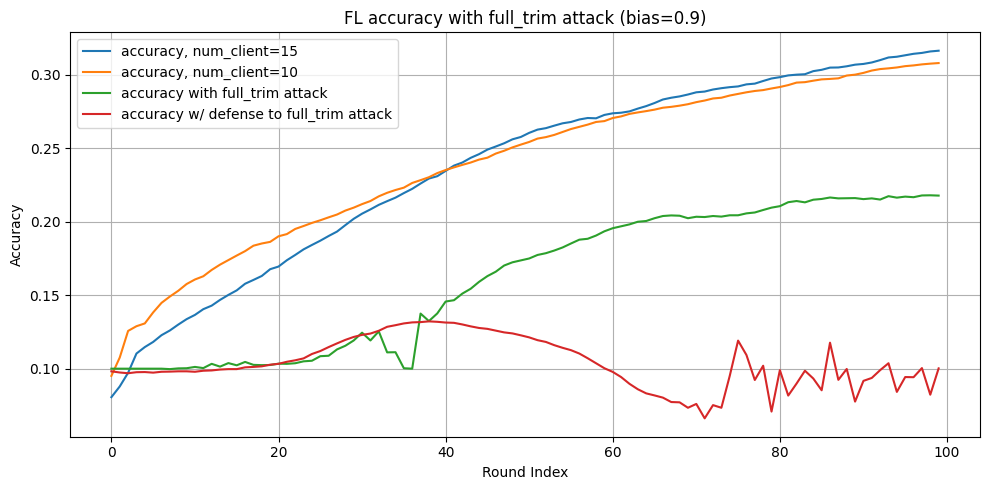

In [188]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9_redo, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_9_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graphing all

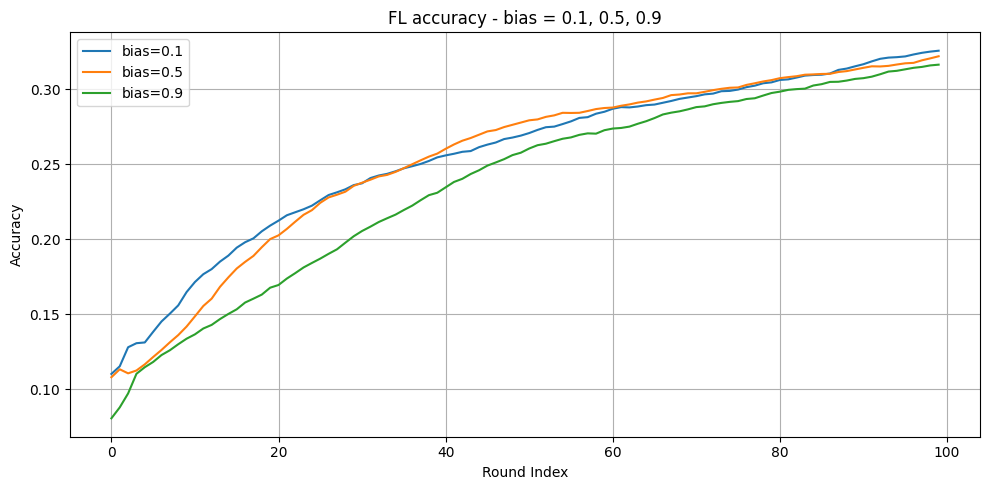

In [217]:
plt.figure(figsize=(10, 5))
plt.plot(accuracies_1, label="bias=0.1")
plt.plot(accuracy_bias_0_5, label="bias=0.5")
plt.plot(accuracy_bias_0_9, label="bias=0.9")

plt.title('FL accuracy - bias = 0.1, 0.5, 0.9')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# CHANGING TO BIAS = 0.9

# bias = 0.9, # of clients = 15





In [205]:
bias = 0.5
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [206]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_105230/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [207]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [208]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [209]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_9

In [178]:
accuracy_bias_0_9_clients_10_redo = []

In [210]:
accuracy_bias_0_5_clients_10_redo = []

In [211]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
#     cnn_optimizer = SGD(net.parameters(), lr = lr)
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        #loss.backward(retain_graph = True)
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))


        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)


        del net_

    #This is the average function. We are taking average of all the client model updates
    #print(len(user_grads))
    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_redo.append(correct/total)

0 0.1099
1 0.1366
2 0.136
3 0.1359
4 0.1369
5 0.1424
6 0.1522
7 0.1621
8 0.1661
9 0.1716
10 0.1769
11 0.1833
12 0.1873
13 0.192
14 0.1957
15 0.1996
16 0.2051
17 0.2095
18 0.2141
19 0.217
20 0.2205
21 0.2251
22 0.2287
23 0.2319
24 0.2339
25 0.237
26 0.239
27 0.242
28 0.2458
29 0.2479
30 0.251
31 0.2539
32 0.2549
33 0.2561
34 0.2586
35 0.2605
36 0.2613
37 0.2638
38 0.2655
39 0.2668
40 0.2681
41 0.2704
42 0.2717
43 0.2737
44 0.2751
45 0.2755
46 0.2763
47 0.2766
48 0.2771
49 0.2783
50 0.2801
51 0.2813
52 0.2828
53 0.2834
54 0.2841
55 0.2844
56 0.2858
57 0.2866
58 0.2871
59 0.2878
60 0.2891
61 0.2913
62 0.2913
63 0.2919
64 0.2934
65 0.294
66 0.2947
67 0.2965
68 0.2973
69 0.2983
70 0.2994
71 0.2995
72 0.3001
73 0.3008
74 0.3016
75 0.303
76 0.3044
77 0.3058
78 0.3066
79 0.3069
80 0.3078
81 0.3082
82 0.3086
83 0.3095
84 0.3104
85 0.3116
86 0.3127
87 0.3144
88 0.3155
89 0.3164
90 0.3169
91 0.3175
92 0.3183
93 0.3196
94 0.3201
95 0.3211
96 0.3213
97 0.3222
98 0.3223
99 0.3232
CPU times: user 3mi